In [1]:
import time
import matplotlib.pyplot as plt

import torch.optim as optim
from torch.utils.data import DataLoader

from Helper import *
from Model import *

In [2]:
# Configuration
IMAGE_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 10_000
TRAIN_SAMPLES_PER_EPOCH = 1024
VAL_SAMPLES_PER_EPOCH = 256
LR = 1e-4

CHECKPOINT_INTERVAL = 100
LOG_INTERVAL = 1
VAL_INTERVAL = 1

DATASET_PATH_TRAIN = "datasets/DIV2K/DIV2K_train_HR"
DATASET_PATH_TEST = "datasets/DIV2K/DIV2K_valid_HR"
CHECKPOINT_DIR = "checkpoints/semantic_segmentation"

# DATASET_CHECKPOINT_TRAIN = CHECKPOINT_DIR + "/train_dataset_checkpoints"
# DATASET_CHECKPOINT_VAL = CHECKPOINT_DIR + "/val_dataset_checkpoints"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
dataset_train = TextSegmentationDataset(
    image_dir=DATASET_PATH_TRAIN,
    checkpoint_dir=CHECKPOINT_DIR,
    length=TRAIN_SAMPLES_PER_EPOCH,
    mode='random'
)

dataset_val = TextSegmentationDataset(
    image_dir=DATASET_PATH_TRAIN,
    checkpoint_dir=CHECKPOINT_DIR,
    length=VAL_SAMPLES_PER_EPOCH,
    mode='pregenerated'
)

train_loader = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

val_loader = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    drop_last=True
)

print(f"Train batches/epoch: {TRAIN_SAMPLES_PER_EPOCH // BATCH_SIZE}")
print(f"Val batches/epoch:   {VAL_SAMPLES_PER_EPOCH // BATCH_SIZE}")

model = UNetTextSegmentation().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

checkpoint = load_checkpoint_generic(CHECKPOINT_DIR, device)

start_epoch = 1
train_losses = []
val_losses = []

best_val_loss = float("inf")

if checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint.get("epoch", 0) + 1
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    best_val_loss = checkpoint.get("best_val_loss", best_val_loss)

    print(f"Resuming from epoch {start_epoch}")
else:
    print("No checkpoint found, starting fresh.")


✓ Random mode: picking from 800 images
✓ Loaded existing dataset checkpoint (pregenerated mode)
Train batches/epoch: 32
Val batches/epoch:   8
Model parameters: 1,928,417
✅ Loaded checkpoint: checkpoints/semantic_segmentation\checkpoint_epoch_1150.pth (epoch 1150)
Resuming from epoch 1151


In [ ]:
print(f"\nStarting training for {EPOCHS} epochs...\n")

for epoch in range(start_epoch, EPOCHS + 1):
    # TRAIN
    model.train()
    epoch_train_loss = 0.0
    batches_seen = 0
    train_start = time.time()

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        batches_seen += 1

    epoch_train_loss /= batches_seen
    train_losses.append(epoch_train_loss)
    train_time = time.time() - train_start

    # VALIDATION
    epoch_val_loss = None
    val_time = None

    if epoch % VAL_INTERVAL == 0:
        model.eval()
        epoch_val_loss = 0.0
        val_batches = 0
        val_start = time.time()

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                logits = model(images)
                loss = criterion(logits, masks)

                epoch_val_loss += loss.item()
                val_batches += 1

        epoch_val_loss /= val_batches
        val_losses.append(epoch_val_loss)
        val_time = time.time() - val_start

    # LOGGING
    if epoch % LOG_INTERVAL == 0:
        log_str = f"Epoch [{epoch:4d}/{EPOCHS}] | Train Loss: {epoch_train_loss:.5f} | Train Time: {train_time:.1f}s"

        if epoch_val_loss is not None:
            log_str += f" | Val Loss: {epoch_val_loss:.5f} | Val Time: {val_time:.1f}s"

        print(log_str)

    # BEST MODEL (only save when validation happened)
    if epoch_val_loss is not None and epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
            },
            CHECKPOINT_DIR / "best_model.pth",
        )
        print(f"✓ Saved best model (Val Loss: {best_val_loss:.5f})")

    # REGULAR CHECKPOINT
    if epoch % CHECKPOINT_INTERVAL == 0:
        save_checkpoint_generic(
            CHECKPOINT_DIR,
            epoch,
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_losses": train_losses,
                "val_losses": val_losses,
                "best_val_loss": best_val_loss,
            },
            max_checkpoints=5,
        )

print("\n🎉 Training completed!")
print(f"📊 Final statistics:")
print(f"  - Best validation loss: {best_val_loss:.6f}")
print(f"  - Total validation points: {len(val_losses)}")
print(f"  - Total training loss logs: {len(train_losses)}")


Starting training for 10000 epochs...



In [4]:
def plot_losses(train_losses, val_losses, val_interval):
    """
    Plot training and validation losses.

    Args:
        train_losses: List of training loss values (one per epoch)
        val_losses: List of validation loss values (one per val_interval epochs)
        val_interval: How often validation occurs (e.g., every 1, 5, 10 epochs)
    """
    # Create epoch arrays
    train_epochs = list(range(1, len(train_losses) + 1))
    val_epochs = list(range(val_interval, len(val_losses) * val_interval + 1, val_interval))

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(train_epochs, train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_epochs, val_losses, label='Val Loss', linewidth=2, marker='o', markersize=4)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

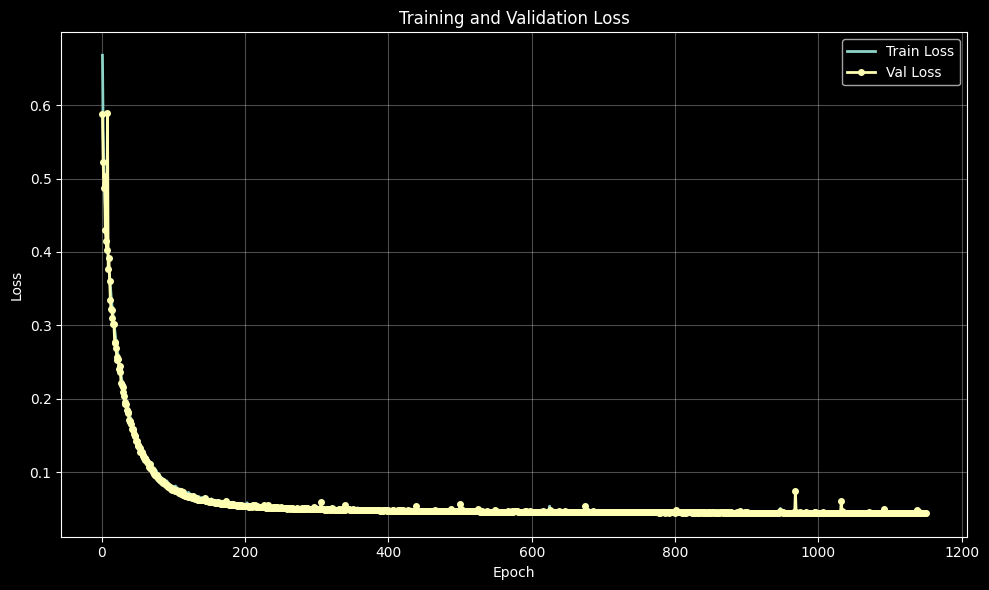

In [5]:
plot_losses(train_losses, val_losses, VAL_INTERVAL)